<a href="https://colab.research.google.com/github/soumeyamokhtari/predictive-maintenance-ai/blob/main/Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
#  PREDICTIVE MAINTENANCE TOOLKIT
# ==============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, accuracy_score, recall_score, PrecisionRecallDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from google.colab import drive
from IPython.display import display

# Mount Google Drive
drive.mount("/content/drive", force_remount=True)

# ==============================================================================
# 1. CORE FUNCTIONS & PIPELINES
# ==============================================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def apply_expert_engineering(df, sensors, window=10):
    df_new = df.copy()
    for col in sensors:
        df_new[f'{col}_FFT'] = df_new[col].shift(1).rolling(window=window).apply(
            lambda x: np.abs(np.fft.fft(x)).mean() if len(x) == window else 0
        ).fillna(0)
        df_new[f'{col}_std'] = df_new[col].shift(1).rolling(window=window).std().bfill()
        df_new[f'{col}_mean'] = df_new[col].shift(1).rolling(window=window).mean().bfill()
    return df_new

def run_tuned_pipeline(X, y, name):
    # Split, Scale, and Pipeline with SMOTE to prevent Data Leakage
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
    ])

    param_grid = {
        'xgb__learning_rate': [0.1, 0.2],
        'xgb__max_depth': [3, 5],
        'xgb__n_estimators': [100, 200]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=kf, scoring='f1')
    grid.fit(X_train_s, y_train)

    best_pipeline = grid.best_estimator_
    best_model = best_pipeline.named_steps['xgb']
    X_res, y_res = best_pipeline.named_steps['smote'].fit_resample(X_train_s, y_train)

    print(f"\n--- {name} OPTIMIZED ---")
    print(f"Best Params: {grid.best_params_}")
    return best_model, X_test_s, y_test, X.columns, X_res, y_res

# ==============================================================================
# 1.5 VISUALISATION & EVALUATION UTILITIES
# ==============================================================================

def compare_before_after(X_raw, y, model_after, X_test_after, y_test_after, name):
    """Compares the naive raw model to the expert engineered model."""
    print(f"\n{'='*20} {name}: BEFORE VS AFTER {'='*20}")

    X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

    naive_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    naive_model.fit(X_train_raw, y_train_raw)

    naive_acc = accuracy_score(y_test_raw, naive_model.predict(X_test_raw))
    naive_cv = cross_val_score(naive_model, X_train_raw, y_train_raw, cv=5).mean()

    tuned_acc = accuracy_score(y_test_after, model_after.predict(X_test_after))
    tuned_cv = cross_val_score(model_after, X_test_after, y_test_after, cv=5).mean()

    results = pd.DataFrame({
        'Metric': ['Test Accuracy', 'Cross-Val Score'],
        'Before (Naive)': [f"{naive_acc:.2%}", f"{naive_cv:.2%}"],
        'After (Expert)': [f"{tuned_acc:.2%}", f"{tuned_cv:.2%}"]
    })
    print(results)

    naive_rec = recall_score(y_test_raw, naive_model.predict(X_test_raw))
    tuned_rec = recall_score(y_test_after, model_after.predict(X_test_after))
    print(f"\nRecall (Failures Caught): {naive_rec:.2%} ---> {tuned_rec:.2%}")

def print_stability_report(model, X_res, y_res, name):
    """Checks if the model is stable using cross-validation."""
    cv_scores = cross_val_score(model, X_res, y_res, cv=kf, scoring='f1')
    print(f"\n--- STABILITY REPORT: {name} ---")
    print(f"Mean F1-Score: {cv_scores.mean():.2%}")
    print(f"Standard Deviation: {cv_scores.std():.4f}")

def print_data_summary(df, name):
    print(f"\n{'='*20} DATA SUMMARY: {name} {'='*20}")
    print(f"Shape: {df.shape}")
    print("\nInfo:")
    df.info()
    print("\nStatistical Description:")
    display(round(df.describe(), 2).T)

def plot_eda_distributions(df, sensors_list, title):
    num_cols = len(sensors_list)
    rows = (num_cols // 3) + (1 if num_cols % 3 != 0 else 0)
    plt.figure(figsize=(15, 3 * rows))
    for i, col in enumerate(sensors_list):
        plt.subplot(rows, 3, i + 1)
        sns.histplot(df[col], kde=True, color='teal')
        plt.title(f'Dist: {col}')
        plt.xlabel(''); plt.ylabel('')
    plt.tight_layout()
    plt.suptitle(title, y=1.02, fontsize=16)
    plt.show()

def plot_eda_boxplots(df, sensors_list, target_col, title):
    num_cols = len(sensors_list)
    rows = (num_cols // 3) + (1 if num_cols % 3 != 0 else 0)
    plt.figure(figsize=(16, 3 * rows))
    for i, col in enumerate(sensors_list):
        plt.subplot(rows, 3, i + 1)
        sns.boxplot(x=target_col, y=col, data=df, hue=target_col, palette='Set2', legend=False)
        plt.title(col)
        plt.xlabel('Failure State (0=Normal, 1=Fail)')
    plt.tight_layout()
    plt.suptitle(title, y=1.02, fontsize=16)
    plt.show()

def plot_correlation_heatmap(df, numeric_cols, title):
    plt.figure(figsize=(12, 10))
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(title, fontsize=15)
    plt.show()

def plot_smote_proof(X_raw, y_raw, title):
    """Temporarily applies SMOTE just to generate the Visual Proof plot."""
    X_s = StandardScaler().fit_transform(X_raw)
    _, y_res = SMOTE(random_state=42).fit_resample(X_s, y_raw)

    before = pd.Series(y_raw).value_counts().sort_index()
    after = pd.Series(y_res).value_counts().sort_index()

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(x=['Normal (0)', 'Fail (1)'], y=before.values, ax=ax[0], hue=['Normal (0)', 'Fail (1)'], palette='Blues_d', legend=False)
    ax[0].set_title(f'BEFORE SMOTE: {title}', fontsize=12, fontweight='bold')
    ax[0].set_ylabel('Number of Samples')

    sns.barplot(x=['Normal (0)', 'Fail (1)'], y=after.values, ax=ax[1], hue=['Normal (0)', 'Fail (1)'], palette='Reds_d', legend=False)
    ax[1].set_title(f'AFTER SMOTE: {title}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_signal_comparison(raw_series, fft_series, name_raw, name_fft):
    plt.figure(figsize=(14, 7))
    plt.subplot(2, 1, 1)
    plt.plot(raw_series.iloc[100:250], color='teal', linewidth=1.5, label=f'Raw {name_raw}')
    plt.title('Stage 1: Raw Sensor Input (Time Domain)', fontsize=14)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(fft_series.iloc[100:250], color='crimson', linewidth=2, label=f'Engineered {name_fft}')
    plt.title('Stage 2: Frequency-Domain Feature (Rolling FFT Mean)', fontsize=14)
    plt.xlabel('Time (Samples)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_evaluation_charts(model, X_test, y_test, title):
    # 1. PR Curve
    y_score = model.predict_proba(X_test)[:, 1]
    plt.figure(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name="XGBoost", color="#8e44ad")
    plt.title(f"Precision-Recall Curve: {title}")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 2. Classification Report Bar Chart
    y_pred = model.predict(X_test)
    print(f"\nDetailed Classification Report ({title}):")
    print(classification_report(y_test, y_pred, digits=4))

    report = classification_report(y_test, y_pred, target_names=['Normal (0)', 'Fail (1)'], output_dict=True)
    df_report = pd.DataFrame(report).iloc[:-1, :2].T

    plt.figure(figsize=(8, 5))
    df_report.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'], ax=plt.gca())
    plt.title(f'Precision, Recall, F1-Score per Class ({title})', fontsize=12)
    plt.ylabel('Score (0.0 to 1.0)')
    plt.xticks(rotation=0)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.show()

def final_report(model, X_test, y_test, cols, name):
    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test), cmap='Blues', ax=plt.gca())
    plt.title(f"Final Matrix: {name}")
    plt.show()

    # SHAP Plot
    plt.figure(figsize=(8, 6))
    explainer = shap.TreeExplainer(model)
    shap_v = explainer.shap_values(X_test)
    shap.summary_plot(shap_v, X_test, feature_names=cols, show=False)
    plt.title(f"SHAP Values: {name}")
    plt.show()

def get_final_metrics(model, X_test, y_test):
    preds = model.predict(X_test)
    return [accuracy_score(y_test, preds), recall_score(y_test, preds), f1_score(y_test, preds)]

Mounted at /content/drive


**DATASET 1 (CHEMICAL)**



PROCESSING DATASET 1: CHEMICAL

==================== DATA SUMMARY: CHEMICAL DATASET ====================
Shape: (944, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB

Statistical Description:


,count,mean,std,min,25%,50%,75%,max
footfall,944.0,306.38,1082.61,0.0,1.0,22.0,110.0,7300.0
tempMode,944.0,3.73,2.68,0.0,1.0,3.0,7.0,7.0
AQ,944.0,4.33,1.44,1.0,3.0,4.0,6.0,7.0
USS,944.0,2.94,1.38,1.0,2.0,3.0,4.0,7.0
CS,944.0,5.39,1.27,1.0,5.0,6.0,6.0,7.0
VOC,944.0,2.84,2.27,0.0,1.0,2.0,5.0,6.0
RP,944.0,47.04,16.42,19.0,34.0,44.0,58.0,91.0
IP,944.0,4.57,1.60,1.0,3.0,4.0,6.0,7.0
Temperature,944.0,16.33,5.97,1.0,14.0,17.0,21.0,24.0
fail,944.0,0.42,0.49,0.0,0.0,0.0,1.0,1.0


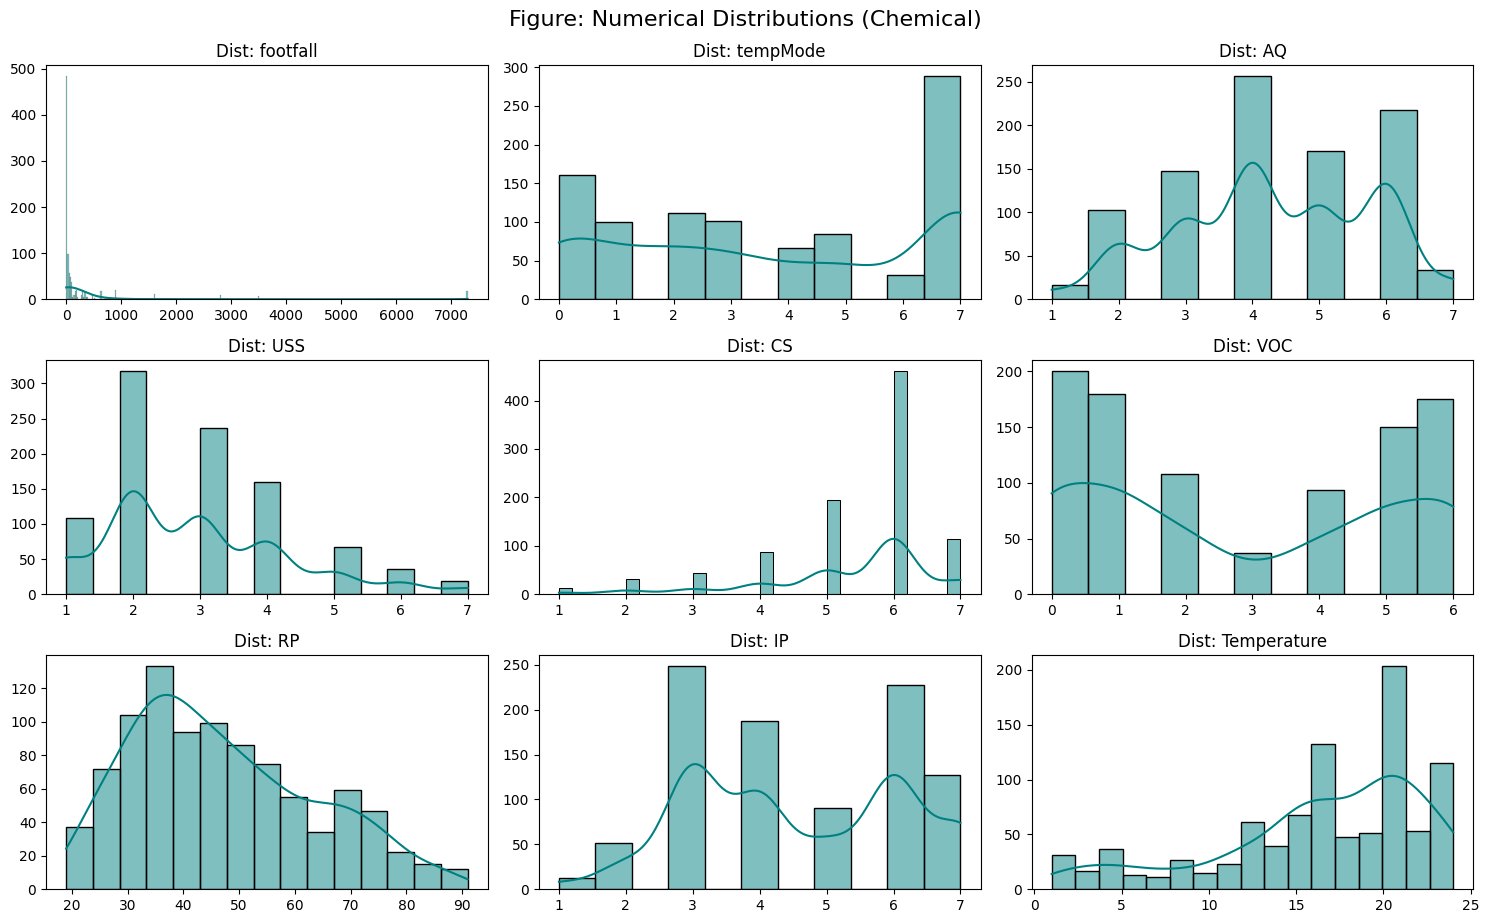

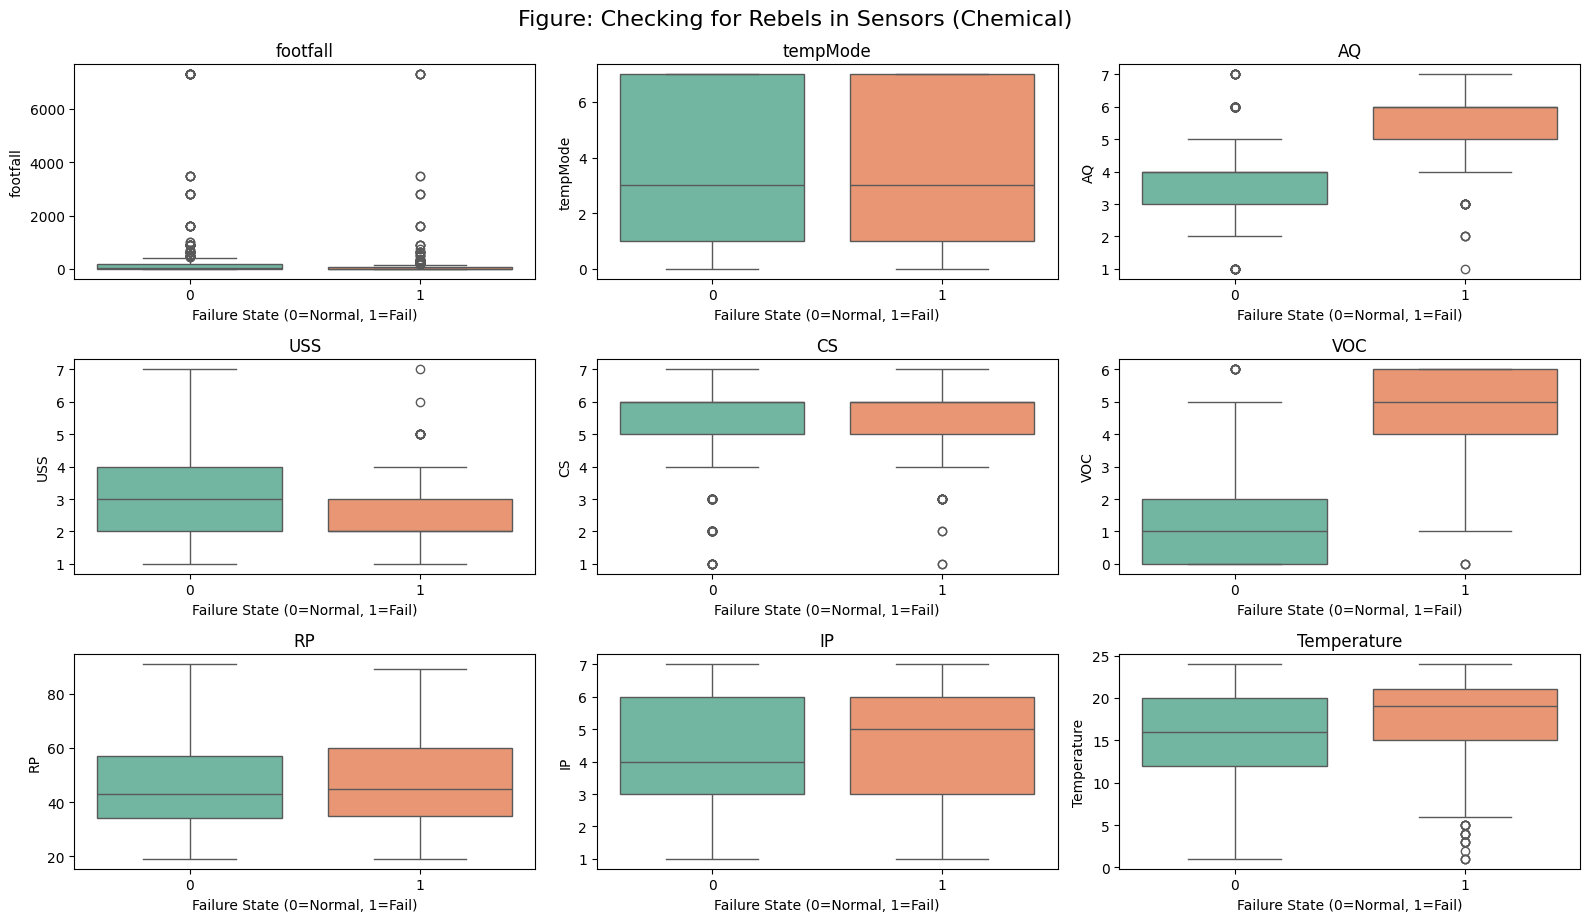

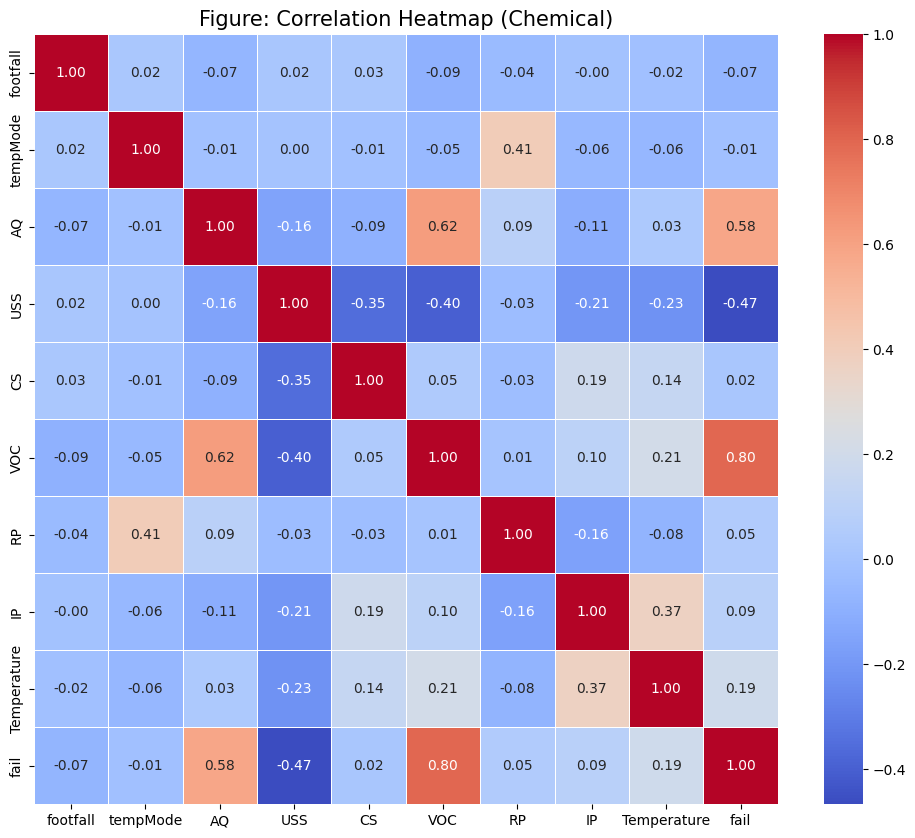

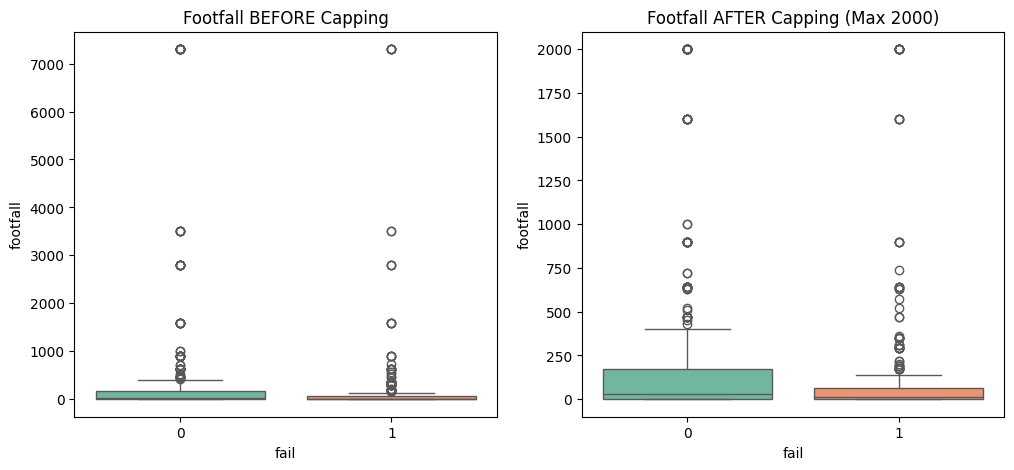

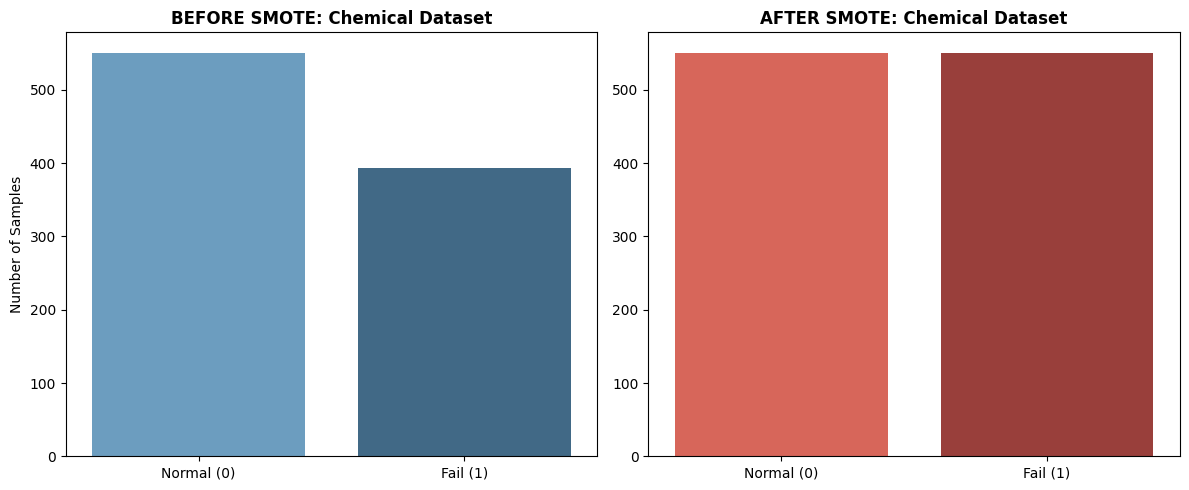

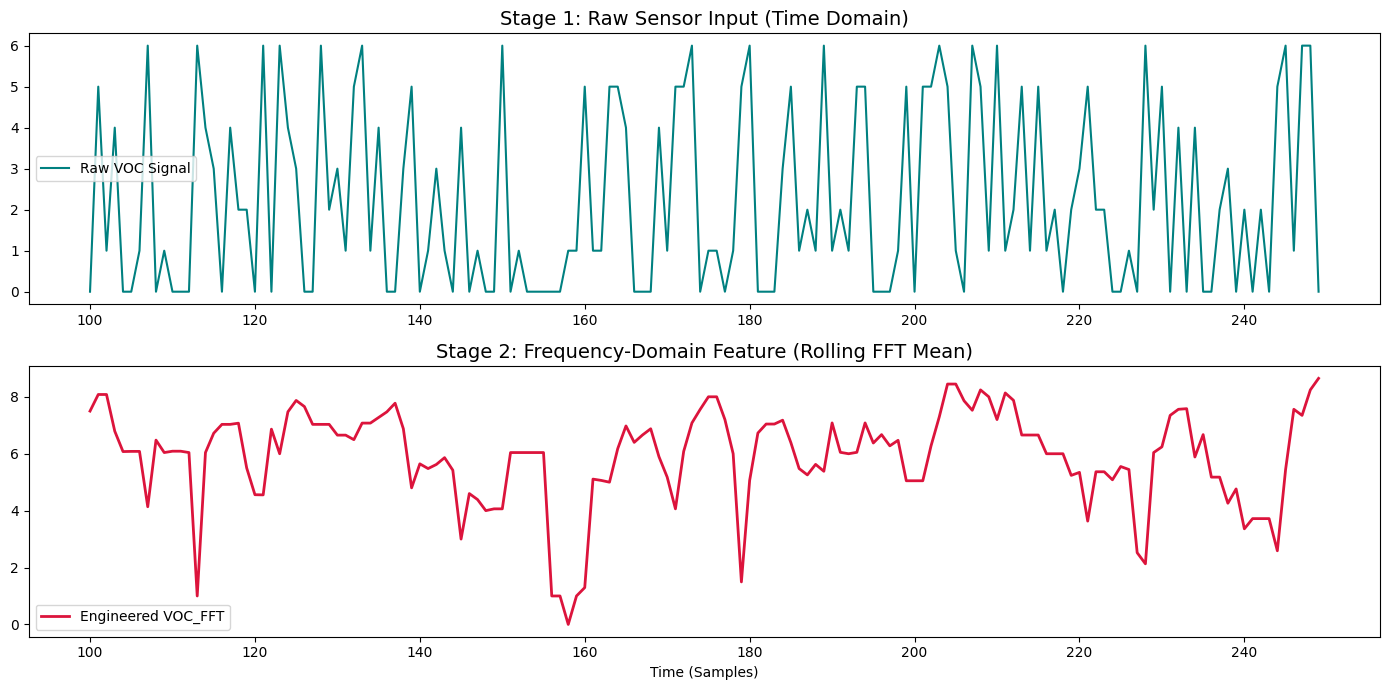


--- CHEMICAL_FFT OPTIMIZED ---
Best Params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200}

==================== CHEMICAL: BEFORE VS AFTER ====================
            Metric Before (Naive) After (Expert)
0    Test Accuracy         91.53%         91.01%
1  Cross-Val Score         89.54%         90.48%

Recall (Failures Caught): 91.14% ---> 89.87%

--- STABILITY REPORT: CHEMICAL (D1) ---
Mean F1-Score: 91.82%
Standard Deviation: 0.0225


<Figure size 600x500 with 0 Axes>

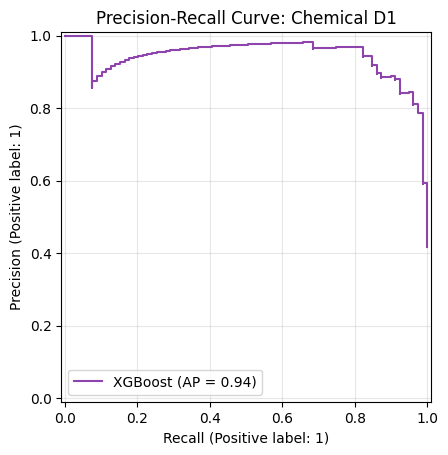


Detailed Classification Report (Chemical D1):
              precision    recall  f1-score   support

           0     0.9266    0.9182    0.9224       110
           1     0.8875    0.8987    0.8931        79

    accuracy                         0.9101       189
   macro avg     0.9071    0.9085    0.9077       189
weighted avg     0.9103    0.9101    0.9101       189



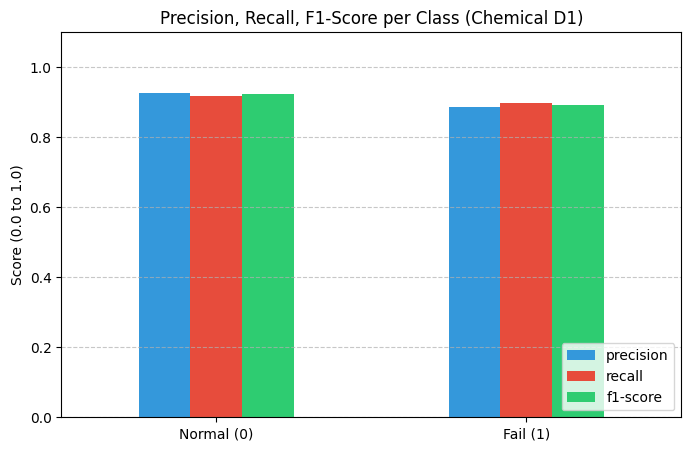

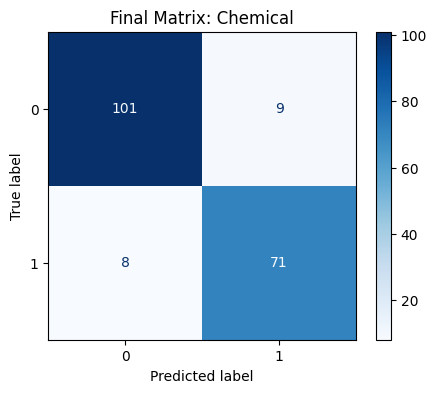

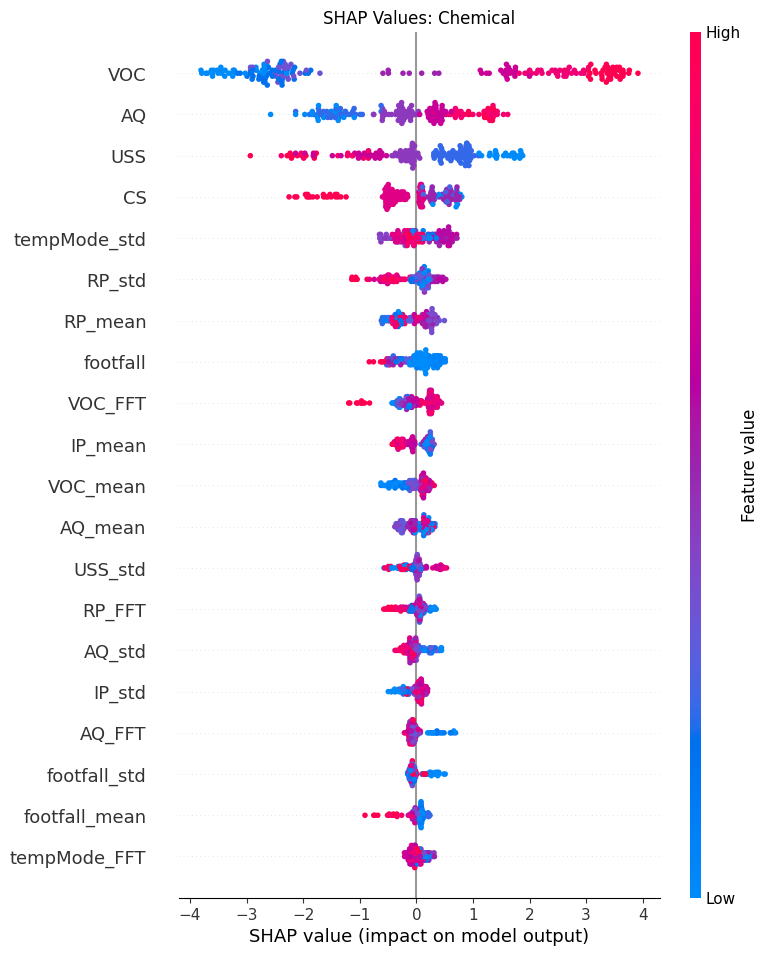

In [ ]:

# ==============================================================================
# 2. DATASET 1 (CHEMICAL)
# ==============================================================================
print("\n\n" + "="*50)
print("PROCESSING DATASET 1: CHEMICAL")
print("="*50)

path1 = '/content/drive/MyDrive/predictive_maintenance_project/Datasets/MachineFailurePrediction /data1.csv'
df1 = pd.read_csv(path1)
print_data_summary(df1, "CHEMICAL DATASET")

y1 = df1['fail']
X1_raw = df1.drop(columns=['fail'])
sensors1 = X1_raw.columns.tolist()

# EDA Visualizations
plot_eda_distributions(df1, sensors1, 'Figure: Numerical Distributions (Chemical)')
plot_eda_boxplots(df1, sensors1, 'fail', 'Figure: Checking for Rebels in Sensors (Chemical)')
plot_correlation_heatmap(df1, sensors1 + ['fail'], 'Figure: Correlation Heatmap (Chemical)')

# Outlier Capping Visual Proof
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df1, x='fail', y='footfall', hue='fail', palette='Set2', legend=False)
plt.title('Footfall BEFORE Capping')
df1['footfall'] = df1['footfall'].clip(upper=2000) # Apply Cap
plt.subplot(1, 2, 2)
sns.boxplot(data=df1, x='fail', y='footfall', hue='fail', palette='Set2', legend=False)
plt.title('Footfall AFTER Capping (Max 2000)')
plt.show()

# SMOTE Visual Proof
X1_raw_capped = df1.drop(columns=['fail'])
plot_smote_proof(X1_raw_capped, y1, "Chemical Dataset")

# Expert Engineering & Visual Proof
X1_final = apply_expert_engineering(X1_raw_capped, sensors1, window=5)
plot_signal_comparison(X1_final['VOC'], X1_final['VOC_FFT'], 'VOC Signal', 'VOC_FFT')

# Modeling & Evaluation
model1, X1_t, y1_t, cols1, X1_r, y1_r = run_tuned_pipeline(X1_final, y1, "CHEMICAL_FFT")
compare_before_after(X1_raw_capped, y1, model1, X1_t, y1_t, "CHEMICAL")
print_stability_report(model1, X1_r, y1_r, "CHEMICAL (D1)")
plot_evaluation_charts(model1, X1_t, y1_t, "Chemical D1")
final_report(model1, X1_t, y1_t, cols1, "Chemical")

**DATASET 2 (MECHANICAL)**



PROCESSING DATASET 2: MECHANICAL

==================== DATA SUMMARY: MECHANICAL DATASET ====================
Shape: (10000, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UDI                    10000 non-null  int64  
 1   Product_ID             10000 non-null  object 
 2   Type                   10000 non-null  int64  
 3   Air_temperature_K      10000 non-null  float64
 4   Process_temperature_K  10000 non-null  float64
 5   Rotational_speed_rpm   10000 non-null  int64  
 6   Torque_Nm              10000 non-null  float64
 7   Tool_wear_min          10000 non-null  int64  
 8   Machine_failure        10000 non-null  int64  
 9   TWF                    10000 non-null  int64  
 10  HDF                    10000 non-null  int64  
 11  PWF                    10000 non-null  int64  
 12  OSF                   

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50,2886.90,1.0,2500.75,5000.5,7500.25,10000.0
Type,10000.0,0.50,0.67,0.0,0.00,0.0,1.00,2.0
Air_temperature_K,10000.0,300.00,2.00,295.3,298.30,300.1,301.50,304.5
Process_temperature_K,10000.0,310.01,1.48,305.7,308.80,310.1,311.10,313.8
Rotational_speed_rpm,10000.0,1538.78,179.28,1168.0,1423.00,1503.0,1612.00,2886.0
Torque_Nm,10000.0,39.99,9.97,3.8,33.20,40.1,46.80,76.6
Tool_wear_min,10000.0,107.95,63.65,0.0,53.00,108.0,162.00,253.0
Machine_failure,10000.0,0.03,0.18,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00,0.07,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01,0.11,0.0,0.00,0.0,0.00,1.0


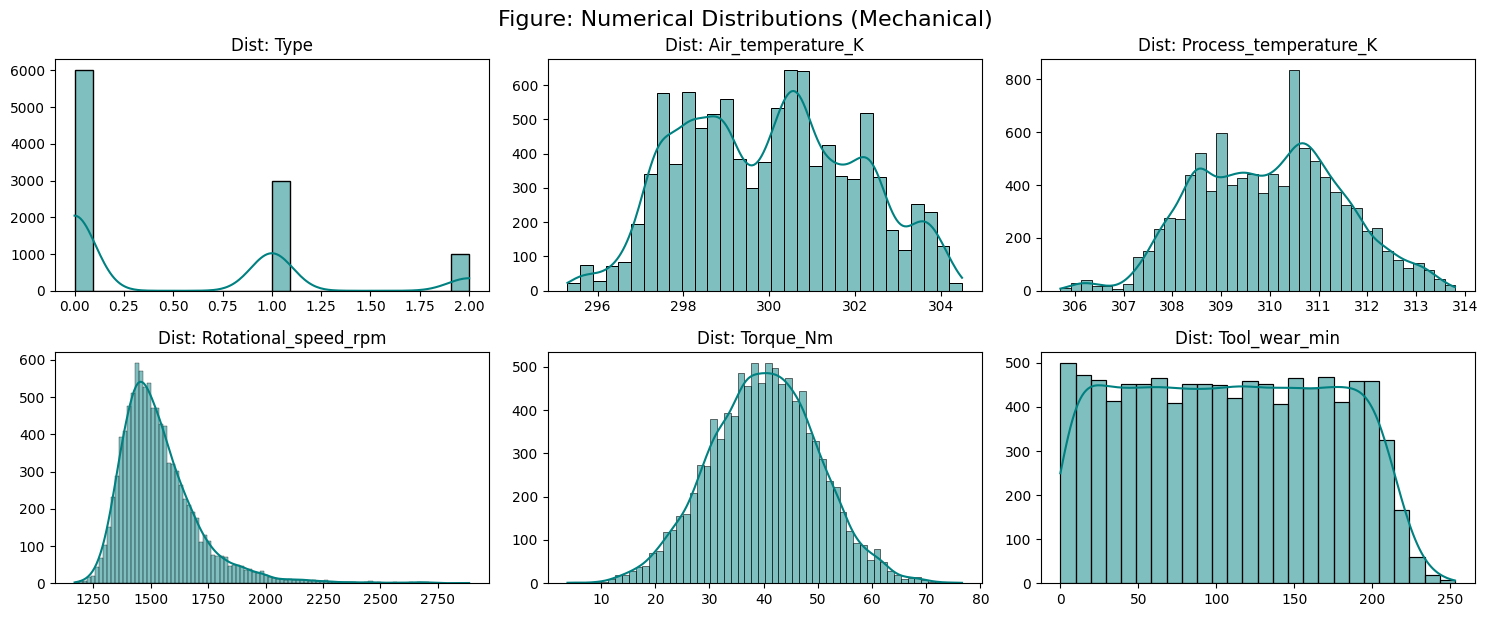

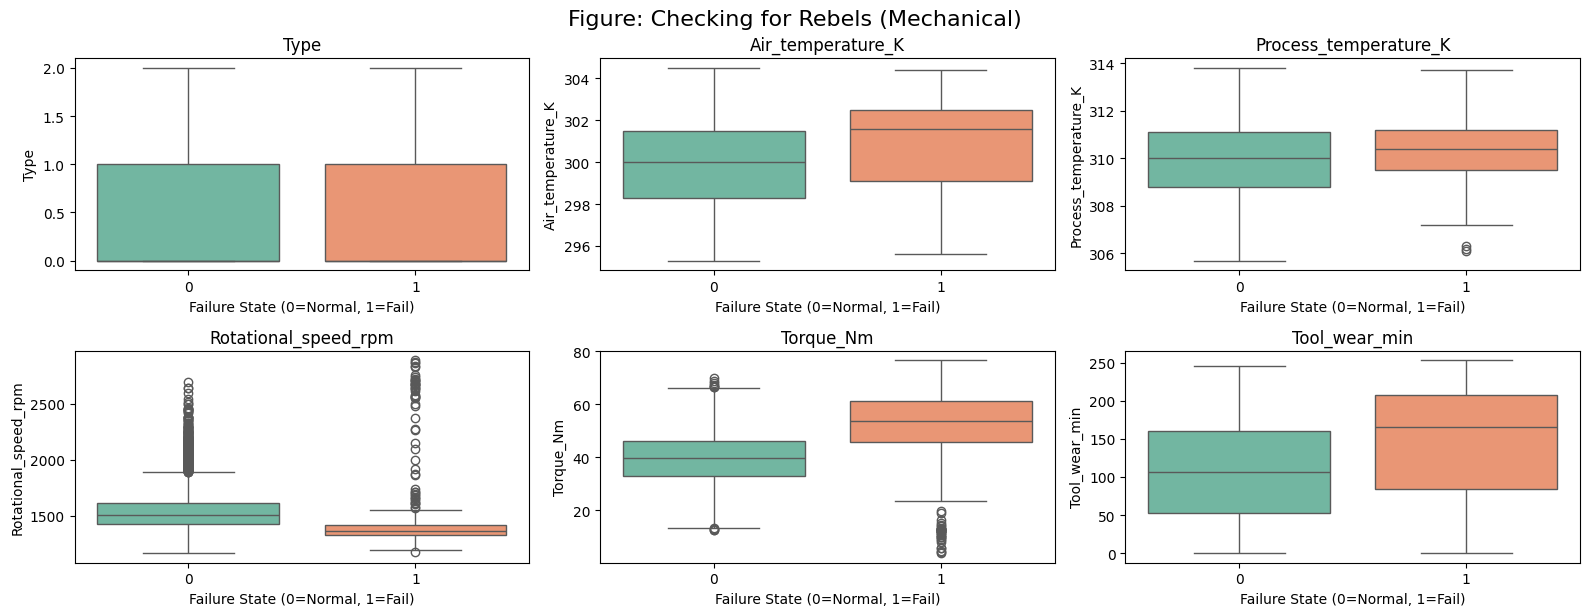

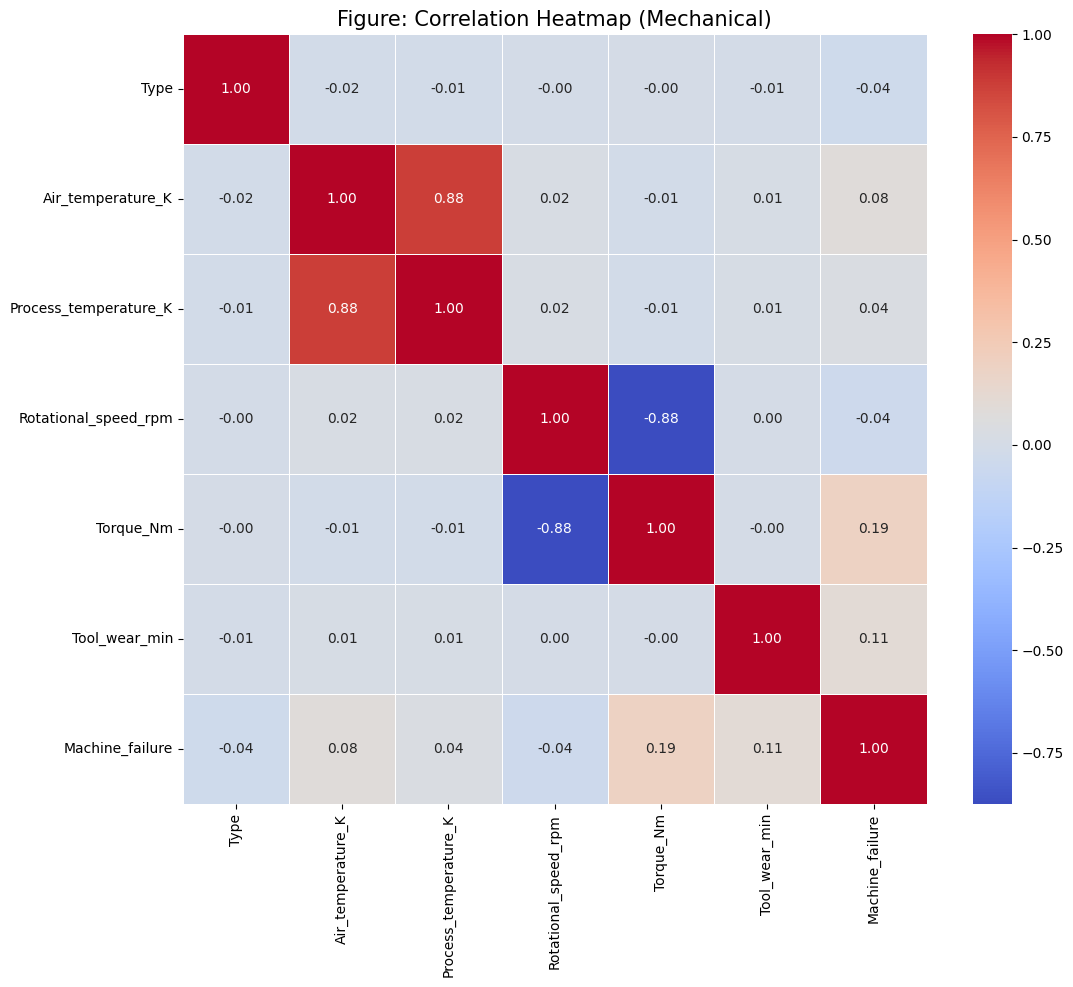

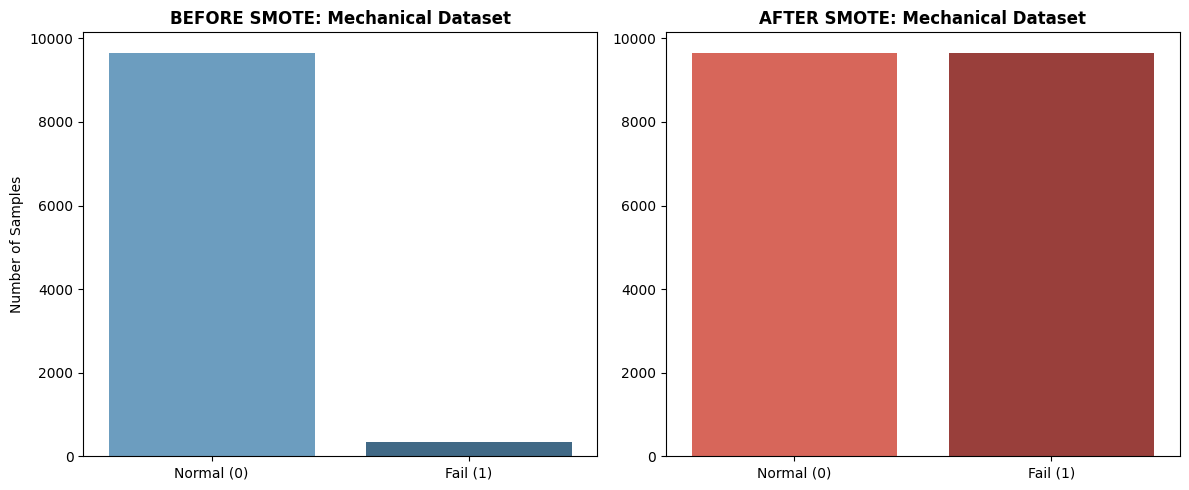

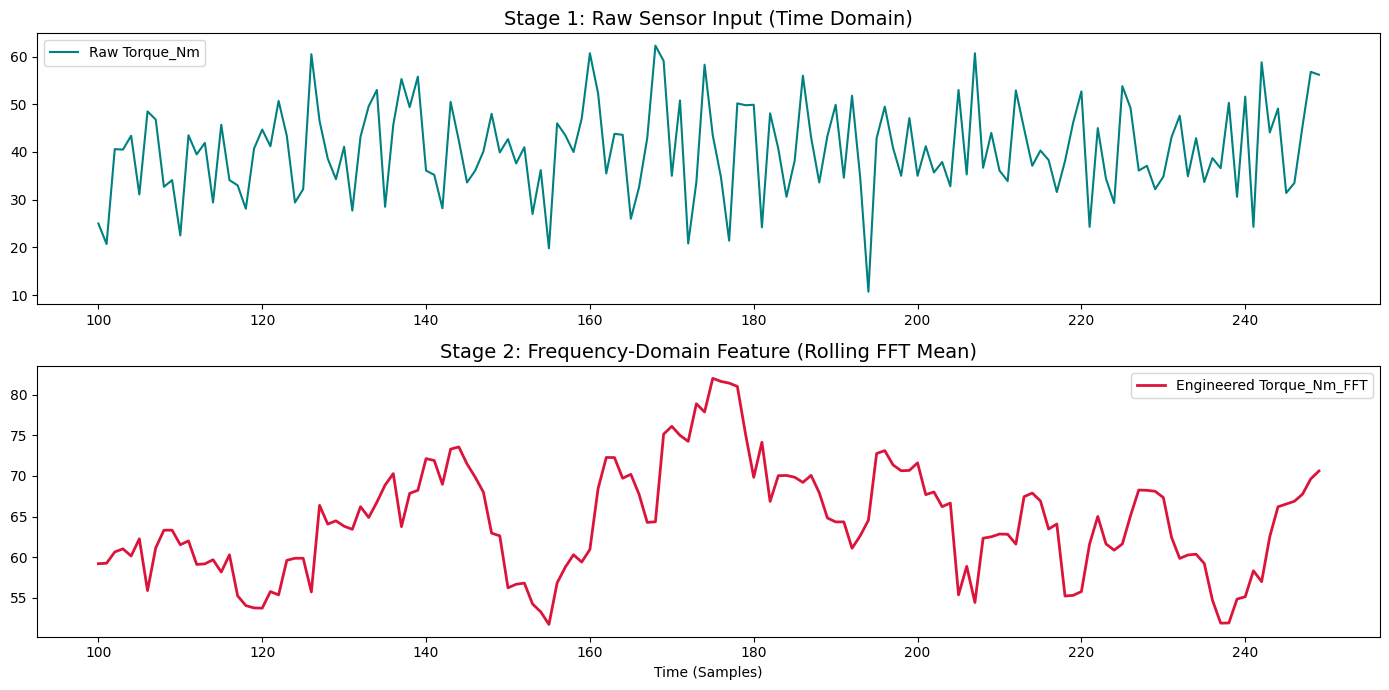


--- MECHANICAL_FFT OPTIMIZED ---
Best Params: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}

==================== MECHANICAL: BEFORE VS AFTER ====================
            Metric Before (Naive) After (Expert)
0    Test Accuracy         98.60%         98.60%
1  Cross-Val Score         98.44%         98.05%

Recall (Failures Caught): 69.12% ---> 80.88%

--- STABILITY REPORT: MECHANICAL (D2) ---
Mean F1-Score: 99.27%
Standard Deviation: 0.0011


<Figure size 600x500 with 0 Axes>

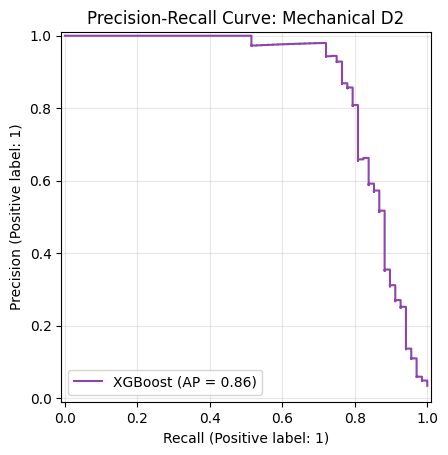


Detailed Classification Report (Mechanical D2):
              precision    recall  f1-score   support

           0     0.9933    0.9922    0.9927      1932
           1     0.7857    0.8088    0.7971        68

    accuracy                         0.9860      2000
   macro avg     0.8895    0.9005    0.8949      2000
weighted avg     0.9862    0.9860    0.9861      2000



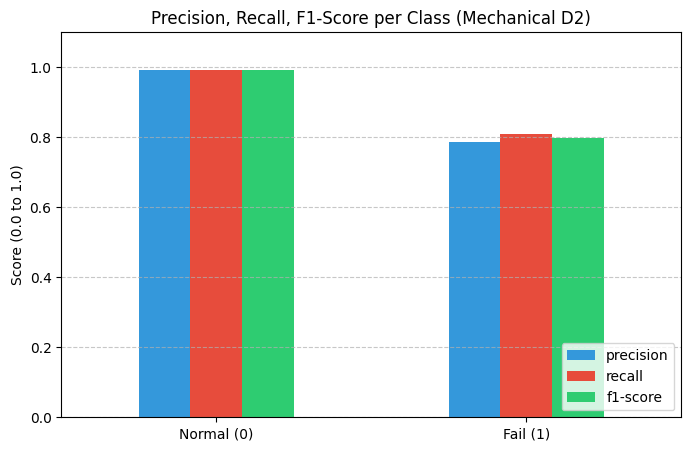

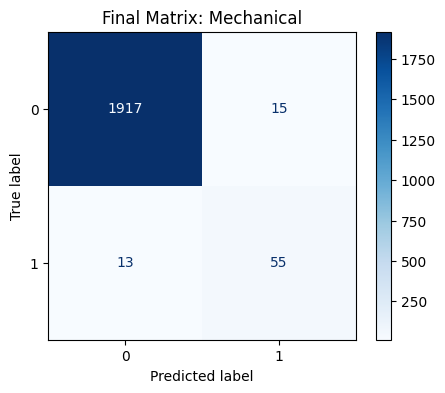

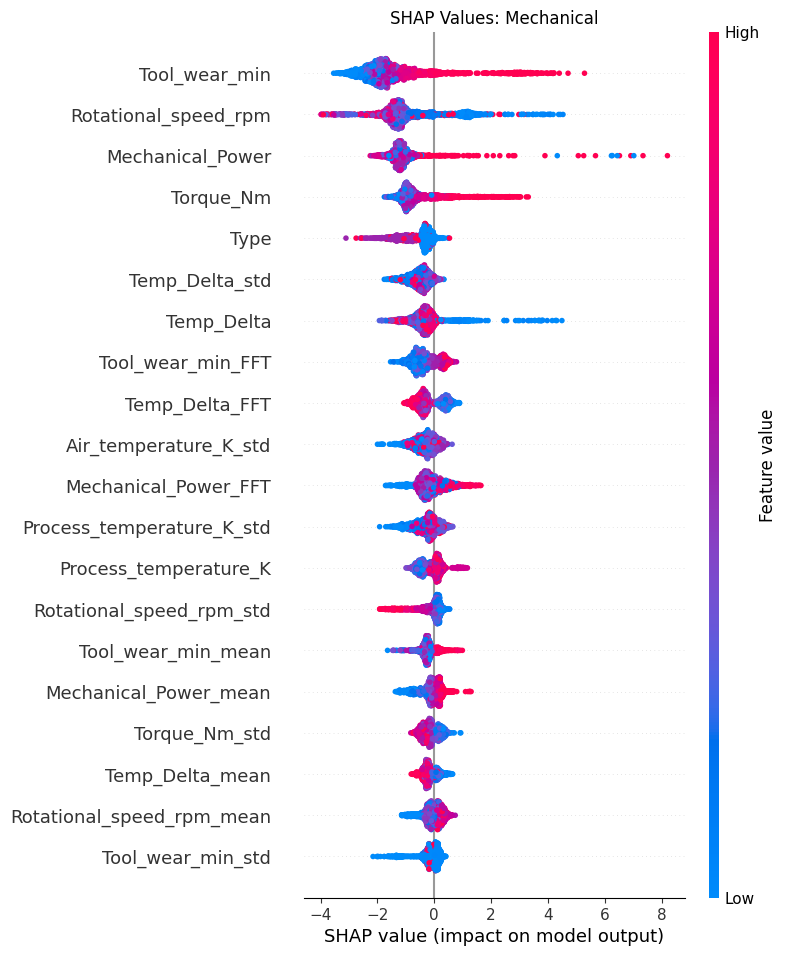

In [ ]:
# ==============================================================================
# 3. DATASET 2 (MECHANICAL)
# ==============================================================================

print("\n\n" + "="*50)
print("PROCESSING DATASET 2: MECHANICAL")
print("="*50)

path2 = '/content/drive/MyDrive/predictive_maintenance_project/Datasets/AIDataset/ai4i2020.csv'
df2 = pd.read_csv(path2)

df2.columns = [col.replace(' [', '_').replace(']', '').replace(' ', '_') for col in df2.columns]
df2['Type'] = df2['Type'].map({'L': 0, 'M': 1, 'H': 2})

print_data_summary(df2, "MECHANICAL DATASET")

y2 = df2['Machine_failure']
X2_eda = df2.drop(columns=['UDI', 'Product_ID', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
sensors2_eda = X2_eda.columns.tolist()

# EDA Visualizations
plot_eda_distributions(df2, sensors2_eda, 'Figure: Numerical Distributions (Mechanical)')
plot_eda_boxplots(df2, sensors2_eda, 'Machine_failure', 'Figure: Checking for Rebels (Mechanical)')
plot_correlation_heatmap(df2, sensors2_eda + ['Machine_failure'], 'Figure: Correlation Heatmap (Mechanical)')

# SMOTE Visual Proof
plot_smote_proof(X2_eda, y2, "Mechanical Dataset")

# Physics & Expert Engineering
df2['Mechanical_Power'] = (df2['Torque_Nm'] * df2['Rotational_speed_rpm'] * 2 * np.pi) / 60
df2['Temp_Delta'] = df2['Process_temperature_K'] - df2['Air_temperature_K']

X2_features_for_fft = df2.drop(columns=['UDI', 'Product_ID', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
sensors2_for_fft = ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Mechanical_Power', 'Temp_Delta']

X2_final = apply_expert_engineering(X2_features_for_fft, sensors2_for_fft, window=10)
plot_signal_comparison(X2_final['Torque_Nm'], X2_final['Torque_Nm_FFT'], 'Torque_Nm', 'Torque_Nm_FFT')

# Modeling & Evaluation
model2, X2_t, y2_t, cols2, X2_r, y2_r = run_tuned_pipeline(X2_final, y2, "MECHANICAL_FFT")
compare_before_after(X2_eda, y2, model2, X2_t, y2_t, "MECHANICAL")
print_stability_report(model2, X2_r, y2_r, "MECHANICAL (D2)")
plot_evaluation_charts(model2, X2_t, y2_t, "Mechanical D2")
final_report(model2, X2_t, y2_t, cols2, "Mechanical")

**FINAL CROSS-DOMAIN COMPARISON**

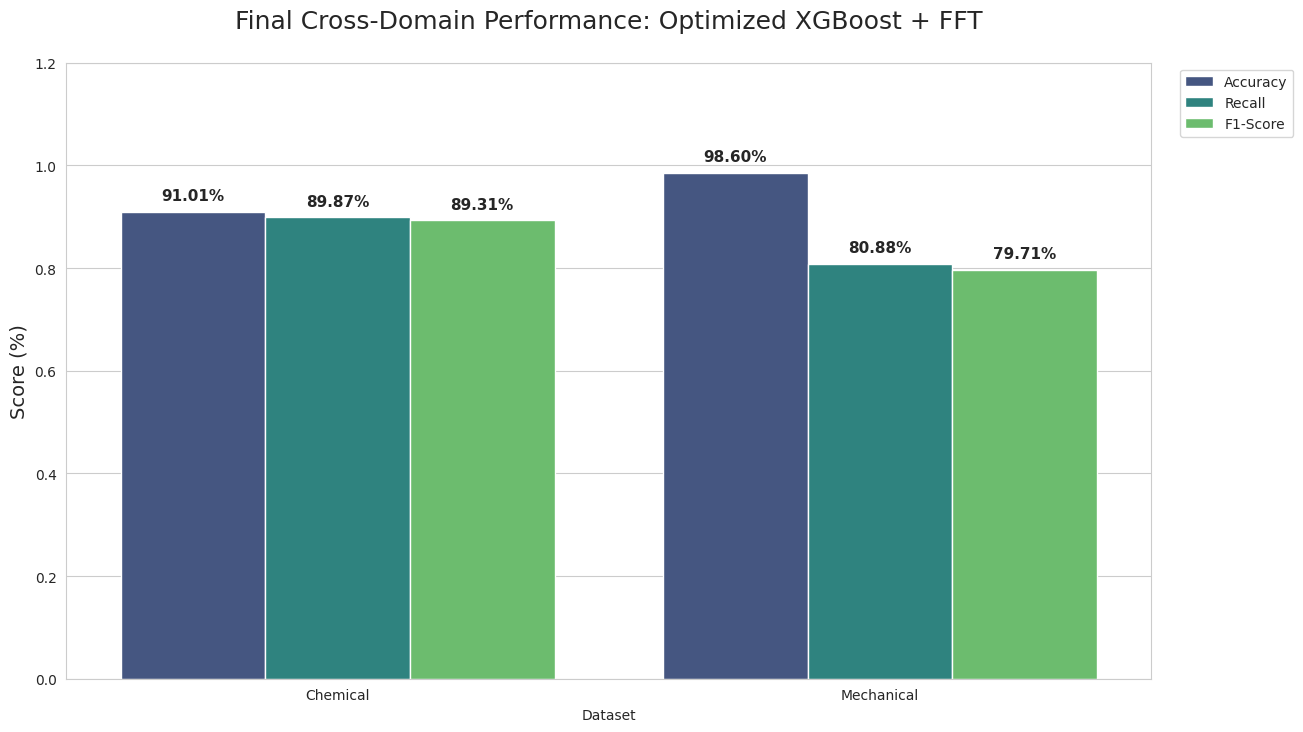

In [ ]:

# ==============================================================================
# 5. FINAL CROSS-DOMAIN COMPARISON
# ==============================================================================

m1 = get_final_metrics(model1, X1_t, y1_t)
m2 = get_final_metrics(model2, X2_t, y2_t)

data = {
    'Dataset': ['Chemical', 'Chemical', 'Chemical', 'Mechanical', 'Mechanical', 'Mechanical'],
    'Metric': ['Accuracy', 'Recall', 'F1-Score', 'Accuracy', 'Recall', 'F1-Score'],
    'Score': m1 + m2
}
df_final_compare = pd.DataFrame(data)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='Dataset', y='Score', hue='Metric', data=df_final_compare, palette="viridis")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2%}', (p.get_x() + p.get_width() / 2., height), ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 8), textcoords='offset points')

plt.title('Final Cross-Domain Performance: Optimized XGBoost + FFT', fontsize=18, pad=25)
plt.ylabel('Score (%)', fontsize=14)
plt.ylim(0, 1.2)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Define your Cost Matrix Assumptions (in £ or $)
cost_fp = 100    # Mechanic wastes 2 hours checking a healthy machine
cost_fn = 10000  # Machine breaks unexpectedly (lost production, damaged parts)
cost_tp = 500    # Planned maintenance (cheap part, scheduled downtime)
cost_tn = 0      # Machine runs perfectly

def calculate_and_display_cost_analysis(model_name, model_instance, X_test, y_test, custom_threshold, cost_fp, cost_fn, cost_tp, cost_tn):
    print(f"\n--- Cost Analysis for {model_name} ---")

    # 1. Get the raw probabilities
    probabilities = model_instance.predict_proba(X_test)[:, 1]

    # 2. Create predictions based on custom threshold
    y_pred_adjusted = (probabilities >= custom_threshold).astype(int)

    # 3. Get the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_adjusted)
    tn, fp, fn, tp = cm.ravel()

    # 4. Calculate the total cost with AI
    ai_maintenance_cost = (fp * cost_fp) + (fn * cost_fn) + (tp * cost_tp) + (tn * cost_tn)

    # 5. Calculate the baseline: Cost without AI (Reactive Maintenance)
    total_actual_failures = tp + fn
    reactive_maintenance_cost = total_actual_failures * cost_fn

    # 6. Calculate money saved
    money_saved = reactive_maintenance_cost - ai_maintenance_cost

    print(f"Cost without AI (Reactive): £{reactive_maintenance_cost:,}")
    print(f"Cost with Optimized Model:  £{ai_maintenance_cost:,}")
    print(f"--------------------------------------------------")
    print(f"Total Money Saved:          £{money_saved:,}")
    print(f"  True Negatives (TN): {tn}")
    print(f"  False Positives (FP): {fp}")
    print(f"  False Negatives (FN): {fn}")
    print(f"  True Positives (TP): {tp}")

# Set the custom threshold
custom_threshold = 0.3

# Evaluate Chemical Model (model1)
calculate_and_display_cost_analysis(
    "Chemical Model (D1)", model1, X1_t, y1_t, custom_threshold,
    cost_fp, cost_fn, cost_tp, cost_tn
)

# Evaluate Mechanical Model (model2)
calculate_and_display_cost_analysis(
    "Mechanical Model (D2)", model2, X2_t, y2_t, custom_threshold,
    cost_fp, cost_fn, cost_tp, cost_tn
)



--- Cost Analysis for Chemical Model (D1) ---
Cost without AI (Reactive): £790,000
Cost with Optimized Model:  £88,400
--------------------------------------------------
Total Money Saved:          £701,600
  True Negatives (TN): 96
  False Positives (FP): 14
  False Negatives (FN): 5
  True Positives (TP): 74

--- Cost Analysis for Mechanical Model (D2) ---
Cost without AI (Reactive): £680,000
Cost with Optimized Model:  £160,000
--------------------------------------------------
Total Money Saved:          £520,000
  True Negatives (TN): 1907
  False Positives (FP): 25
  False Negatives (FN): 13
  True Positives (TP): 55
